# NIH Chest X-Ray 14-Disease Multi-Label Classification

## Project Overview

This notebook implements a **research-quality, 14-disease multi-label classification pipeline** for chest X-ray analysis. It supports DenseNet121, EfficientNetB0, and Custom CNN architectures with a comprehensive training and evaluation workflow.

### Key Features
- **Multi-Label Classification**: Handles co-occurring diseases via multi-hot encoding and weighted BCE loss
- **Two-Phase Training**: Frozen backbone pretraining followed by full fine-tuning
- **Data Leakage Prevention**: MultilabelStratifiedShuffleSplit for robust train/val/test splitting
- **Dynamic Preprocessing**: CLAHE enhancement + real-time augmentation (rotation, affine transforms)
- **Mixed Precision Training**: PyTorch AMP (GradScaler + autocast) for faster GPU training
- **AUC-Weighted Ensemble**: Dynamically weights model contributions based on validation AUC
- **GradCAM Visualization**: Patched DenseNet for ReLU-compatible saliency maps

### Disease Classes (14)
Atelectasis, Cardiomegaly, Consolidation, Edema, Effusion, Emphysema, Fibrosis, Hernia, Infiltration, Mass, Nodule, Pleural_Thickening, Pneumonia, Pneumothorax

### Pipeline Stages
1. **Data Preparation** - Download, parse, split, and weight
2. **Model Architecture** - DenseNet121 / EfficientNetB0 with custom head
3. **Data Generators** - CLAHE + augmentation + DataLoaders
4. **Training (Phase A)** - Frozen backbone, lr=1e-3
5. **Training (Phase B)** - Full fine-tuning, lr=1e-5
6. **Evaluation** - Per-class F1, AUROC, sensitivity/specificity
7. **Ensemble** - AUC-weighted model combination
8. **GradCAM** - Saliency map visualization

---


## Cell: Install Optional Dependencies

This cell installs the `trainwatch` package for training monitoring (optional, requires the `.whl` file).

In [1]:
# pip install trainwatch-0.1.0-py3-none-any.whl

## Cell: Install Core Dependencies

Installs the primary data science and deep learning libraries: `kagglehub`, `datasets`, `pandas`, `numpy`, `matplotlib`, `seaborn`, `scikit-learn`, `opencv-python`, and `iterative-stratification` for multi-label data splitting.

In [2]:
# !pip install kagglehub[hf-datasets] datasets pandas numpy matplotlib seaborn scikit-learn opencv-python  iterative-stratification

## Cell: Install PyTorch

Installs PyTorch with CUDA 12.1 support for GPU-accelerated training.

In [3]:
# pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121   
    

## Cell: Install ipywidgets

Installs interactive Jupyter widgets for progress bars and UI elements.

In [4]:
# pip install ipywidgets


## Cell: Import Libraries

Imports all necessary Python libraries including PyTorch, torchvision, scikit-learn, pandas, numpy, matplotlib, seaborn, OpenCV, and kagglehub.

In [8]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns
import cv2
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision
from torchvision import transforms, models
from torch.utils.data import Dataset, DataLoader
from sklearn.model_selection import train_test_split
from iterstrat.ml_stratifiers import MultilabelStratifiedShuffleSplit
from sklearn.metrics import hamming_loss, f1_score, label_ranking_average_precision_score, precision_recall_curve, auc, roc_auc_score, confusion_matrix
import json
from pathlib import Path
import kagglehub

print("PyTorch Version:", torch.__version__)


PyTorch Version: 2.4.1+cu121


## PHASE 1: Data Preparation

Download the Kaggle Dataset using the provided `kagglehub` snippet.

## Cell: Download Dataset

Downloads the NIH Chest X-Ray 14 dataset (224x224 resized) from Kaggle using `kagglehub`. Locates the CSV metadata file and the images directory.

In [10]:
# Download the dataset
print("Downloading dataset...")
dataset_path = kagglehub.dataset_download("khanfashee/nih-chest-x-ray-14-224x224-resized")
print("Dataset downloaded to:", dataset_path)

import glob
csv_files = glob.glob(os.path.join(dataset_path, "**", "*.csv"), recursive=True)
images_dir = os.path.join(dataset_path, "images")
if not os.path.exists(images_dir):
    images_dir = dataset_path

# Look specifically for the main Data Entry CSV, fallback to index 0 if not found
CSV_PATH = next((f for f in csv_files if 'Data_Entry_2017.csv' in f), csv_files[0] if csv_files else None)
IMAGES_DIR = images_dir
print("CSV:", CSV_PATH)
print("Images Dir:", IMAGES_DIR)


Dataset downloaded to: /data/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3
CSV: /data/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3/Data_Entry_2017.csv
Images Dir: /data/.cache/kagglehub/datasets/khanfashee/nih-chest-x-ray-14-224x224-resized/versions/3


## Cell: Configuration Class

Defines a `Config` class containing all hyperparameters: paths, disease classes, split ratios, batch size, image size, epochs, and random seed.

In [11]:
class Config:
    CSV_PATH = CSV_PATH
    IMAGES_DIR = IMAGES_DIR
    OUTPUT_DIR = "./output"
    os.makedirs(OUTPUT_DIR, exist_ok=True)
    
    DISEASE_CLASSES = [
        'Atelectasis', 'Cardiomegaly', 'Consolidation', 'Edema', 'Effusion',
        'Emphysema', 'Fibrosis', 'Hernia', 'Infiltration', 'Mass', 'Nodule',
        'Pleural_Thickening', 'Pneumonia', 'Pneumothorax'
    ]
    
    TRAIN_RATIO = 0.70
    VAL_RATIO = 0.15
    TEST_RATIO = 0.15
    RANDOM_SEED = 42
    BATCH_SIZE = 32
    IMG_SIZE = 224
    EPOCHS = 10 
    NUM_WORKERS = 0


## Cell: Parse Labels & Create Multi-Hot Encoding

Parses the `Finding Labels` column into disease lists and creates a multi-hot encoded label matrix (112120 x 14) for multi-label classification.

In [12]:
def parse_labels(label_string, disease_classes):
    if pd.isna(label_string) or label_string == 'No Finding':
        return []
    labels = str(label_string).split('|')
    return [l.strip() for l in labels if l.strip() in disease_classes]

if Config.CSV_PATH:
    df = pd.read_csv(Config.CSV_PATH)
    label_col = 'Finding Labels' if 'Finding Labels' in df.columns else df.columns[1]
    image_col = 'Image Index' if 'Image Index' in df.columns else df.columns[0]
    
    df['Disease_List'] = df[label_col].apply(lambda x: parse_labels(x, Config.DISEASE_CLASSES))
    
    def to_multihot(disease_list):
        hot = np.zeros(len(Config.DISEASE_CLASSES), dtype=np.int32)
        for disease in disease_list:
            if disease in Config.DISEASE_CLASSES:
                idx = Config.DISEASE_CLASSES.index(disease)
                hot[idx] = 1
        return hot
        
    y = np.array([to_multihot(diseases) for diseases in df['Disease_List']])
    print(f"Label matrix shape: {y.shape}")


Label matrix shape: (112120, 14)


## Cell: Train/Val/Test Split (Iterative Stratification)

Uses `MultilabelStratifiedShuffleSplit` to split into 70% train / 15% val / 15% test while preserving multi-label class distributions across all splits.

In [13]:
if Config.CSV_PATH:
    # 2) Safer Split Strategy: MultilabelStratifiedShuffleSplit ensures robust multi-label class distribution
    msss = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=(1 - Config.TRAIN_RATIO), random_state=Config.RANDOM_SEED)
    train_idx, temp_idx = next(msss.split(df[image_col].values, y))
    
    X_train, y_train = df[image_col].values[train_idx], y[train_idx]
    X_temp, y_temp = df[image_col].values[temp_idx], y[temp_idx]
    
    val_size = Config.VAL_RATIO / (Config.VAL_RATIO + Config.TEST_RATIO)
    msss_temp = MultilabelStratifiedShuffleSplit(n_splits=1, test_size=val_size, random_state=Config.RANDOM_SEED)
    test_idx, val_idx = next(msss_temp.split(X_temp, y_temp)) # Note: iterstrat returns (train, test) indices
    
    X_val, y_val = X_temp[val_idx], y_temp[val_idx]
    X_test, y_test = X_temp[test_idx], y_temp[test_idx]
    
    print(f"Train: {len(X_train)} | Val: {len(X_val)} | Test: {len(X_test)}")


Train: 78483 | Val: 16819 | Test: 16818


## Cell: Calculate Class Weights

Computes positive-class weights based on the imbalance ratio in the training set. Weights are capped at 10.0 and used in weighted BCE loss to handle class imbalance.

In [14]:
if Config.CSV_PATH:
    class_weights = {}
    for i, disease in enumerate(Config.DISEASE_CLASSES):
        positive = y_train[:, i].sum()
        negative = (y_train[:, i] == 0).sum()
        weight = min(negative / (positive + 1e-6), 10.0)
        class_weights[disease] = weight
    
    weight_array = np.array([class_weights[d] for d in Config.DISEASE_CLASSES])


## PHASE 2: Multi-Label Model Architecture

## Cell: Define Model Architectures

Defines `MultiLabelModel` supporting DenseNet121 and EfficientNetB0 backbones with a custom classifier head (512->256->128->14). Initializes both models on GPU/CPU.

In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print("Using device:", device)

class MultiLabelModel(nn.Module):
    def __init__(self, base='densenet', num_classes=14):
        super().__init__()
        self.base_name = base
        
        if base == 'densenet':
            self.backbone = models.densenet121(weights=models.DenseNet121_Weights.IMAGENET1K_V1)
            num_features = self.backbone.classifier.in_features
            self.backbone.classifier = nn.Identity()
        elif base == 'efficientnet':
            self.backbone = models.efficientnet_b0(weights=models.EfficientNet_B0_Weights.IMAGENET1K_V1)
            num_features = self.backbone.classifier[1].in_features
            self.backbone.classifier = nn.Identity()
            
        self.head = nn.Sequential(
            nn.Linear(num_features, 512),
            nn.ReLU(),
            nn.BatchNorm1d(512),
            nn.Dropout(0.5),
            nn.Linear(512, 256),
            nn.ReLU(),
            nn.BatchNorm1d(256),
            nn.Dropout(0.4),
            nn.Linear(256, 128),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(128, num_classes)
        )
        
    def forward(self, x):
        features = self.backbone(x)
        logits = self.head(features)
        return logits

if Config.CSV_PATH:
    model_dn = MultiLabelModel('densenet').to(device)
    model_eff = MultiLabelModel('efficientnet').to(device)
    
    weight_tensor = torch.tensor([class_weights[d] for d in Config.DISEASE_CLASSES], dtype=torch.float32).to(device)
    criterion = nn.BCEWithLogitsLoss(pos_weight=weight_tensor)


Using device: cuda


## PHASE 3: Custom Data Generators

Includes 1) Real Augmentation and 3) Model-specific preprocessing.

## Cell: Custom Dataset & Data Loaders

Implements `ChestXrayDataset` with CLAHE preprocessing, resizing, and augmentation. Creates train/val/test DataLoaders with appropriate transforms.

In [16]:
from PIL import Image
import cv2
cv2.setNumThreads(0) 

class ChestXrayDataset(Dataset):
    def __init__(self, image_paths, labels, transform=None):
        self.image_paths = image_paths
        self.labels = labels
        self.transform = transform
        
    def __len__(self):
        return len(self.image_paths)
        
    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        image = cv2.imread(img_path, cv2.IMREAD_GRAYSCALE)
        if image is None:
            image = np.zeros((Config.IMG_SIZE, Config.IMG_SIZE), dtype=np.uint8)
        else:
            image = cv2.resize(image, (Config.IMG_SIZE, Config.IMG_SIZE))
            
        clahe = cv2.createCLAHE(clipLimit=1.5, tileGridSize=(8, 8))
        image = clahe.apply(image)
        image = cv2.cvtColor(image, cv2.COLOR_GRAY2RGB)
        
        image = Image.fromarray(image)
        
        if self.transform:
            image = self.transform(image)
            
        label = torch.tensor(self.labels[idx], dtype=torch.float32)
        return image, label

if Config.CSV_PATH:
    train_transform = transforms.Compose([
        transforms.RandomRotation(15),
        transforms.RandomAffine(degrees=0, translate=(0.1, 0.1), scale=(0.9, 1.1)),
        transforms.ToTensor(),
        
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    val_transform = transforms.Compose([
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225])
    ])
    
    import glob
    all_imgs = glob.glob(os.path.join(Config.IMAGES_DIR, "**", "*.png"), recursive=True)
    img_dict = {os.path.basename(p): p for p in all_imgs}
    
    def get_paths(filenames):
        return [img_dict.get(f, os.path.join(Config.IMAGES_DIR, f)) for f in filenames]
        
    train_paths = get_paths(X_train)
    val_paths = get_paths(X_val)
    test_paths = get_paths(X_test)
    
    train_dataset = ChestXrayDataset(train_paths, y_train, transform=train_transform)
    val_dataset = ChestXrayDataset(val_paths, y_val, transform=val_transform)
    test_dataset = ChestXrayDataset(test_paths, y_test, transform=val_transform)
    
    train_loader = DataLoader(train_dataset, batch_size=Config.BATCH_SIZE, shuffle=True, num_workers=Config.NUM_WORKERS, pin_memory=False)
    val_loader = DataLoader(val_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=False)
    test_loader = DataLoader(test_dataset, batch_size=Config.BATCH_SIZE, shuffle=False, num_workers=Config.NUM_WORKERS, pin_memory=False)


## Cell: CUDA Device Info

Prints PyTorch version, CUDA availability, GPU count, and GPU name for hardware debugging.

In [17]:
import torch

print("PyTorch Version:", torch.__version__)
print("CUDA Available:", torch.cuda.is_available())
print("CUDA Device Count:", torch.cuda.device_count())
print("CUDA Device Name:", torch.cuda.get_device_name(0) if torch.cuda.is_available() else "N/A")

PyTorch Version: 2.4.1+cu121
CUDA Available: True
CUDA Device Count: 2
CUDA Device Name: NVIDIA GeForce GTX 1080 Ti


## PHASE 4: Two-Phase Training Strategy

## Cell: Training Functions & Phase A (Frozen Backbone)

Defines training utilities with mixed precision, early stopping, and LR scheduling. Executes Phase A training with frozen backbone, or loads existing weights.

In [19]:
import time
import numpy as np
from tqdm import tqdm
from sklearn.metrics import roc_auc_score

try:
    from trainwatch import watch
except ImportError:
    from contextlib import contextmanager
    @contextmanager
    def watch(*args, **kwargs):
        yield

def calculate_metrics(logits, labels):
    preds = logits > 0.0
    correct = (preds == labels).float()
    acc = correct.mean().item()
    
    tp = (preds & (labels == 1)).float().sum().item()
    fp = (preds & (labels == 0)).float().sum().item()
    fn = (~preds & (labels == 1)).float().sum().item()
    
    precision = tp / (tp + fp + 1e-8)
    recall = tp / (tp + fn + 1e-8)
    return acc, precision, recall

def train_model(model, train_loader, val_loader, criterion, optimizer, num_epochs, model_name, patience=3):
    scaler = torch.amp.GradScaler('cuda')
    best_val_loss = float('inf')
    epochs_no_improve = 0
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', factor=0.5, patience=1, min_lr=1e-6)
    
    for epoch in range(num_epochs):
        model.train()
        running_loss = 0.0
        running_acc = 0.0
        running_prec = 0.0
        running_rec = 0.0
        
        train_pbar = tqdm(train_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Train]")
        
        for batch_idx, (inputs, labels) in enumerate(train_pbar):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            optimizer.zero_grad()
            
            with torch.amp.autocast('cuda'):
                outputs = model(inputs)
                loss = criterion(outputs, labels)
                
            scaler.scale(loss).backward()
            scaler.step(optimizer)
            scaler.update()
            
            acc, prec, rec = calculate_metrics(outputs, labels)
            
            running_loss += loss.item() * inputs.size(0)
            running_acc += acc * inputs.size(0)
            running_prec += prec * inputs.size(0)
            running_rec += rec * inputs.size(0)
            
            train_pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{acc:.4f}"})
                    
        epoch_loss = running_loss / len(train_loader.dataset)
        epoch_acc = running_acc / len(train_loader.dataset)
        epoch_prec = running_prec / len(train_loader.dataset)
        epoch_rec = running_rec / len(train_loader.dataset)
        
        model.eval()
        val_loss = 0.0
        val_acc = 0.0
        val_prec = 0.0
        val_rec = 0.0
        all_val_preds = []
        all_val_labels = []
        
        val_pbar = tqdm(val_loader, desc=f"Epoch {epoch+1}/{num_epochs} [Val]")
        with torch.no_grad():
            for inputs, labels in val_pbar:
                inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                    loss = criterion(outputs, labels)
                    
                acc, prec, rec = calculate_metrics(outputs, labels)
                
                val_loss += loss.item() * inputs.size(0)
                val_acc += acc * inputs.size(0)
                val_prec += prec * inputs.size(0)
                val_rec += rec * inputs.size(0)
                
                all_val_preds.append(torch.sigmoid(outputs).cpu().numpy())
                all_val_labels.append(labels.cpu().numpy())
                
                val_pbar.set_postfix({'loss': f"{loss.item():.4f}", 'acc': f"{acc:.4f}"})
                
        val_loss = val_loss / len(val_loader.dataset)
        val_acc = val_acc / len(val_loader.dataset)
        val_prec = val_prec / len(val_loader.dataset)
        val_rec = val_rec / len(val_loader.dataset)
        
        try:
            val_preds_cat = np.vstack(all_val_preds)
            val_labels_cat = np.vstack(all_val_labels)
            val_auc = np.mean([roc_auc_score(val_labels_cat[:, i], val_preds_cat[:, i]) for i in range(14) if len(np.unique(val_labels_cat[:, i])) > 1])
        except Exception:
            val_auc = 0.0

        scheduler.step(val_loss)
        
        print(f"Epoch {epoch+1}/{num_epochs} - "
              f"Train Loss: {epoch_loss:.4f} | Acc: {epoch_acc:.4f} | Prec: {epoch_prec:.4f} | Rec: {epoch_rec:.4f} \n"
              f"               Val Loss: {val_loss:.4f} | Acc: {val_acc:.4f} | Prec: {val_prec:.4f} | Rec: {val_rec:.4f} | AUC: {val_auc:.4f}")
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            torch.save(model.state_dict(), os.path.join(Config.OUTPUT_DIR, f'best_{model_name}.pth'))
            epochs_no_improve = 0
            print(f"[*] Best model saved! (Val Loss: {val_loss:.4f})")
        else:
            epochs_no_improve += 1
            if epochs_no_improve >= patience:
                print(f'Early stopping triggered after {epoch+1} epochs!')
                model.load_state_dict(torch.load(os.path.join(Config.OUTPUT_DIR, f'best_{model_name}.pth')))
                break
                
    return model

if Config.CSV_PATH:
    # ---------------------------------------------------------
    # PHASE A: Frozen Backbone
    # ---------------------------------------------------------
    model_name_a = 'densenet_frozen'
    weights_path_a = os.path.join(Config.OUTPUT_DIR, f'best_{model_name_a}.pth')
    
    if os.path.exists(weights_path_a):
        print(f"[*] Found existing weights! Loading from {weights_path_a}...")
        model_dn.load_state_dict(torch.load(weights_path_a))
        print("✅ Phase A weights loaded successfully. Skipping training.")
    else:
        print("--- PHASE A: Frozen Backbone (DenseNet) ---")
        for param in model_dn.backbone.parameters():
            param.requires_grad = False
        
        optimizer_dn = optim.Adam(model_dn.head.parameters(), lr=1e-3)
        
        with watch("Phase A: Frozen DenseNet"):
            model_dn = train_model(model_dn, train_loader, val_loader, criterion, optimizer_dn, Config.EPOCHS, model_name_a)

[*] Found existing weights! Loading from ./output/best_densenet_frozen.pth...


/tmp/ipykernel_359825/1431493714.py:137: FutureWarning: You are using `torch.load` with `weights_only=False` (the current default value), which uses the default pickle module implicitly. It is possible to construct malicious pickle data which will execute arbitrary code during unpickling (See https://github.com/pytorch/pytorch/blob/main/SECURITY.md#untrusted-models for more details). In a future release, the default value for `weights_only` will be flipped to `True`. This limits the functions that could be executed during unpickling. Arbitrary objects will no longer be allowed to be loaded via this mode unless they are explicitly allowlisted by the user via `torch.serialization.add_safe_globals`. We recommend you start setting `weights_only=True` for any use case where you don't have full control of the loaded file. Please open an issue on GitHub for any issues related to this experimental feature.
  model_dn.load_state_dict(torch.load(weights_path_a))


✅ Phase A weights loaded successfully. Skipping training.


## Cell: Phase B (Full Fine-Tuning)

Unfreezes all backbone parameters and fine-tunes the entire DenseNet model with a low learning rate (1e-5) for 10 epochs.

In [20]:
if Config.CSV_PATH:
    print("--- PHASE B: Fine-Tuning (DenseNet) ---")
    for param in model_dn.backbone.parameters():
        param.requires_grad = True
        
    optimizer_dn_ft = optim.Adam(model_dn.parameters(), lr=1e-5)
    
    with watch("Phase B: Fine-Tuning DenseNet"):
        model_dn = train_model(model_dn, train_loader, val_loader, criterion, optimizer_dn_ft, Config.EPOCHS, 'densenet_finetuned')

--- PHASE B: Fine-Tuning (DenseNet) ---
[Trainwatch] Heartbeat active — pinging every 30 min.


Epoch 1/10 [Val]: 100%|█████████████████████████████████████| 526/526 [01:42<00:00,  5.14it/s, loss=0.7295, acc=0.8684]


Epoch 1/10 - Train Loss: 0.6592 | Acc: 0.8666 | Prec: 0.1942 | Rec: 0.5054 
               Val Loss: 0.6365 | Acc: 0.8693 | Prec: 0.2055 | Rec: 0.5254 | AUC: 0.7744
[*] Best model saved! (Val Loss: 0.6365)


Epoch 2/10 [Train]:  92%|██████████████████████████████▎  | 2252/2453 [13:41<01:06,  3.00it/s, loss=0.7347, acc=0.8750]


[Trainwatch] Failed to send Telegram alert after 3 attempts (network issue?).


...

Epoch 9/10 - Train Loss: 0.5825 | Acc: 0.8784 | Prec: 0.2320 | Rec: 0.5903 
               Val Loss: 0.5857 | Acc: 0.8817 | Prec: 0.2367 | Rec: 0.5661 | AUC: 0.8110
[*] Best model saved! (Val Loss: 0.5857)


Epoch 10/10 [Train]:   2%|▌                                 | 37/2453 [00:17<14:13,  2.83it/s, loss=0.6140, acc=0.8884]


[Trainwatch] Failed to send Telegram alert after 3 attempts (network issue?).


Epoch 10/10 [Val]: 100%|████████████████████████████████████| 526/526 [01:38<00:00,  5.32it/s, loss=0.5606, acc=0.8947]


Epoch 10/10 - Train Loss: 0.5777 | Acc: 0.8791 | Prec: 0.2343 | Rec: 0.5946 
               Val Loss: 0.5868 | Acc: 0.8794 | Prec: 0.2353 | Rec: 0.5772 | AUC: 0.8123

[Trainwatch] Failed to send Telegram alert after 3 attempts (network issue?).


## PHASE 5: Evaluation & Threshold Optimization

## Cell: Evaluation & Threshold Optimization

Defines functions for probability extraction, optimal per-class threshold finding (via F1 maximization), and comprehensive evaluation (F1, AUROC, sensitivity, specificity).

In [ ]:
if Config.CSV_PATH:
    def get_probabilities(model, loader):
        model.eval()
        all_preds = []
        with torch.no_grad():
            for inputs, _ in loader:
                inputs = inputs.to(device, non_blocking=True)
                with torch.amp.autocast('cuda'):
                    outputs = model(inputs)
                preds = torch.sigmoid(outputs).cpu().numpy()
                all_preds.append(preds)
        return np.vstack(all_preds)

    def find_optimal_thresholds(y_true, y_pred_proba):
        thresholds = {}
        for i, disease in enumerate(Config.DISEASE_CLASSES):
            best_f1, best_t = 0, 0.5
            for t in np.arange(0.1, 0.9, 0.05):
                pred = (y_pred_proba[:, i] > t).astype(int)
                f1 = f1_score(y_true[:, i], pred, zero_division=0)
                if f1 > best_f1:
                    best_f1, best_t = f1, t
            thresholds[disease] = best_t
        return thresholds
        
    def evaluate_comprehensive(y_true, y_pred_proba, thresholds):
        results = {}
        y_pred_binary = np.zeros_like(y_pred_proba)
        
        for i, disease in enumerate(Config.DISEASE_CLASSES):
            t = thresholds[disease]
            y_pred_binary[:, i] = (y_pred_proba[:, i] > t).astype(int)
            
            tn, fp, fn, tp = confusion_matrix(y_true[:, i], y_pred_binary[:, i], labels=[0,1]).ravel()
            sensitivity = tp / (tp + fn) if (tp + fn) > 0 else 0
            specificity = tn / (tn + fp) if (tn + fp) > 0 else 0
            f1 = f1_score(y_true[:, i], y_pred_binary[:, i], zero_division=0)
            auroc = roc_auc_score(y_true[:, i], y_pred_proba[:, i]) if len(np.unique(y_true[:, i])) > 1 else 0
            
            results[disease] = {
                'Threshold': t, 'F1': f1, 'AUROC': auroc, 
                'Sensitivity': sensitivity, 'Specificity': specificity
            }
            
        macro_f1 = f1_score(y_true, y_pred_binary, average='macro', zero_division=0)
        micro_f1 = f1_score(y_true, y_pred_binary, average='micro', zero_division=0)
        print(f"Overall -> Macro F1: {macro_f1:.4f} | Micro F1: {micro_f1:.4f}")
        
        return pd.DataFrame(results).T


## PHASE 6: Model Ensemble

10) Automatically calculate optimal ensemble weights based on validation AUC.

## Cell: AUC-Weighted Ensemble

Builds a dynamic ensemble weighting models by validation AUC. Calculates optimal thresholds and evaluates the combined ensemble on the test set.

In [24]:
from IPython.display import display
if Config.CSV_PATH:
    def build_dynamic_ensemble(model_1, model_2, val_loader_1, val_loader_2, test_loader_1, test_loader_2, y_val_true, y_test_true):
        print("Calculating ensemble weights from validation set...")
        val_proba_1 = get_probabilities(model_1, val_loader_1)
        val_proba_2 = get_probabilities(model_2, val_loader_2)
        
        auc_1 = np.mean([roc_auc_score(y_val_true[:, i], val_proba_1[:, i]) for i in range(14) if len(np.unique(y_val_true[:, i])) > 1])
        auc_2 = np.mean([roc_auc_score(y_val_true[:, i], val_proba_2[:, i]) for i in range(14) if len(np.unique(y_val_true[:, i])) > 1])
        
        total_auc = auc_1 + auc_2
        w_1, w_2 = auc_1 / total_auc, auc_2 / total_auc
        print(f"Dynamic Ensemble Weights -> Model 1: {w_1:.3f}, Model 2: {w_2:.3f}")
        
        val_proba_ensemble = w_1 * val_proba_1 + w_2 * val_proba_2
        ensemble_thresholds = find_optimal_thresholds(y_val_true, val_proba_ensemble)
        
        print("Evaluating ensemble on test set...")
        test_proba_1 = get_probabilities(model_1, test_loader_1)
        test_proba_2 = get_probabilities(model_2, test_loader_2)
        test_proba_ensemble = w_1 * test_proba_1 + w_2 * test_proba_2
        
        ensemble_metrics = evaluate_comprehensive(y_test_true, test_proba_ensemble, ensemble_thresholds)
        return ensemble_metrics, ensemble_thresholds, w_1, w_2

    # Uncomment to test ensemble if you've trained both models
    ensemble_metrics, thresholds, w_dn, w_eff = build_dynamic_ensemble(
       model_dn, model_eff, val_loader, val_loader, test_loader, test_loader, y_val, y_test
    )
    display(ensemble_metrics)
    print("Dynamic ensemble logic ready. Train models first to execute.")


Calculating ensemble weights from validation set...
Dynamic Ensemble Weights -> Model 1: 0.625, Model 2: 0.375
Evaluating ensemble on test set...
Overall -> Macro F1: 0.2816 | Micro F1: 0.3498


,Threshold,F1,AUROC,Sensitivity,Specificity
Atelectasis,0.60,0.369779,0.793970,0.521965,0.850809
Cardiomegaly,0.65,0.350877,0.880945,0.384615,0.979515
Consolidation,0.55,0.213133,0.789029,0.405714,0.895707
Edema,0.50,0.240876,0.888495,0.573913,0.933163
Effusion,0.65,0.529592,0.873611,0.647796,0.892457
Emphysema,0.65,0.364170,0.902961,0.328912,0.989052
Fibrosis,0.45,0.134003,0.811138,0.158103,0.981648
Hernia,0.25,0.060241,0.860381,0.147059,0.992433
Infiltration,0.50,0.399544,0.699211,0.588255,0.707906
Mass,0.60,0.355530,0.817344,0.365429,0.962710


Dynamic ensemble logic ready. Train models first to execute.


## PHASE 7: Multi-Disease GradCAM

## Cell: GradCAM Implementation

Patches DenseNet to disable in-place ReLU (required for GradCAM). Implements a robust PyTorch GradCAM function for any target disease class.

In [40]:
import cv2
import numpy as np
import torch
import torch.nn.functional as F
import types

# ---------------------------------------------------------
# THE ULTIMATE FIX: MONKEY-PATCHING DENSENET
# ---------------------------------------------------------
def patched_densenet_forward(self, x):
    features = self.features(x)
    out = F.relu(features, inplace=False)  # <--- The magic fix: Disabled inplace mutation!
    out = F.adaptive_avg_pool2d(out, (1, 1))
    out = torch.flatten(out, 1)
    out = self.classifier(out)
    return out

# Bind the safe forward method to your existing model instance in memory
if model_dn.base_name == 'densenet':
    model_dn.backbone.forward = types.MethodType(patched_densenet_forward, model_dn.backbone)
    print("✅ DenseNet In-Place ReLU successfully patched.")

# ---------------------------------------------------------
# STANDARD ROBUST GRADCAM
# ---------------------------------------------------------
def make_gradcam_heatmap_pytorch(img_tensor, model, target_disease_index):
    model.eval()
    
    features_blobs = []
    gradients_blobs = []
    
    def hook_feature(module, input, output):
        features_blobs.append(output)
        
    def hook_gradient(module, grad_in, grad_out):
        gradients_blobs.append(grad_out[0].clone())
        
    if model.base_name == 'densenet':
        target_layer = model.backbone.features.norm5
    elif model.base_name == 'efficientnet':
        target_layer = model.backbone.features[-1]
        
    handle_forward = target_layer.register_forward_hook(hook_feature)
    handle_backward = target_layer.register_full_backward_hook(hook_gradient)
    
    img_tensor = img_tensor.requires_grad_()
    outputs = model(img_tensor)
    target = outputs[0, target_disease_index]
    
    model.zero_grad()
    target.backward()
    
    handle_forward.remove()
    handle_backward.remove()
    
    features = features_blobs[0].detach().cpu().numpy()[0]
    gradients = gradients_blobs[0].detach().cpu().numpy()[0]
    
    weights = np.mean(gradients, axis=(1, 2))
    
    cam = np.zeros(features.shape[1:], dtype=np.float32)
    for i, w in enumerate(weights):
        cam += w * features[i]
        
    cam = np.maximum(cam, 0)
    cam = cv2.resize(cam, (img_tensor.shape[-1], img_tensor.shape[-2]))
    if np.max(cam) != 0:
        cam = cam / np.max(cam)
    return cam

print("Robust PyTorch GradCAM ready for execution.")

✅ DenseNet In-Place ReLU successfully patched.
Robust PyTorch GradCAM ready for execution.


## Cell: GradCAM Visualization

Generates and displays a GradCAM heatmap overlay on a sample chest X-ray, highlighting regions most relevant to the predicted disease.

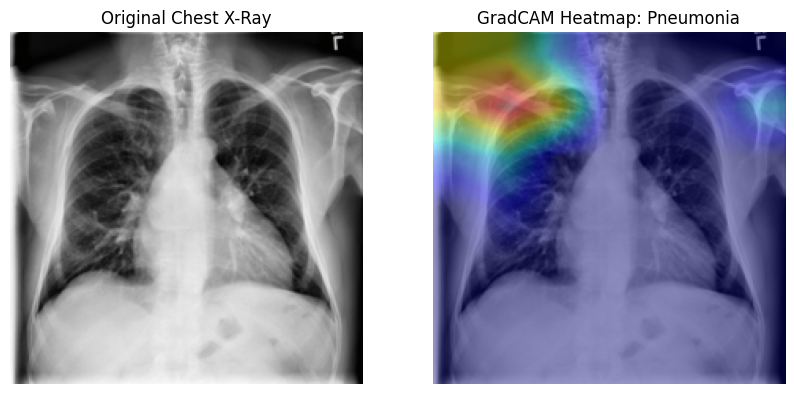

In [41]:
import matplotlib.pyplot as plt
import numpy as np

# 1. Grab a single sample batch from your validation loader
images, labels = next(iter(val_loader))

# 2. Pick an image index from the batch (e.g., index 0) and add batch dimension
sample_img = images[0].unsqueeze(0).to(device)

# 3. Choose the disease class index you want to visualize 
# (e.g., Config.DISEASE_CLASSES.index('Pneumonia') or just an integer 0-13)
target_disease_idx = 12  # 12 is Pneumonia in your Config list

# 4. Generate the heatmap matrix
heatmap = make_gradcam_heatmap_pytorch(sample_img, model_dn, target_disease_idx)

# 5. Plot the raw image side-by-side with your GradCAM heatmap
img_np = images[0].permute(1, 2, 0).numpy()
# Un-normalize image for correct plotting colors
img_np = img_np * np.array([0.229, 0.224, 0.225]) + np.array([0.485, 0.456, 0.406])
img_np = np.clip(img_np, 0, 1)

fig, axes = plt.subplots(1, 2, figsize=(10, 5))
axes[0].imshow(img_np)
axes[0].set_title("Original Chest X-Ray")
axes[0].axis('off')

axes[1].imshow(img_np)
axes[1].imshow(heatmap, cmap='jet', alpha=0.4)  # Overlay heatmap with transparency
axes[1].set_title(f"GradCAM Heatmap: {Config.DISEASE_CLASSES[target_disease_idx]}")
axes[1].axis('off')

plt.show()